In [2]:
# Breast Cancer Classifier and Grad-CAM Visualizer (Midterm Version)
# Author: Ruy Perez
# Date: 2025-09-22
# Description: Trains a CNN to classify breast cancer images from CBIS-DDSM and visualizes the prediction using Grad-CAM

# Cell 0: Install and import essential dependencies
!pip -q install kaggle opencv-python gradio scikit-learn
import tensorflow as tf, random, pathlib, os, glob, re, shutil, zipfile
print("TF:", tf.__version__)

TF: 2.20.0


In [3]:
# Cell 1: Upload Kaggle API token (kaggle.json)
from google.colab import files
print("Upload kaggle.json")
files.upload()
home = pathlib.Path("~/.kaggle").expanduser()
home.mkdir(exist_ok=True)
os.rename("kaggle.json", home/"kaggle.json")
os.chmod(home/"kaggle.json", 0o600)
print("OK")

Upload kaggle.json


Saving kaggle.json to kaggle.json
OK


In [5]:
# Cell 2: Download and extract the CBIS-DDSM dataset
!kaggle datasets download -d awsaf49/cbis-ddsm-breast-cancer-image-dataset -p /content -q
z = "/content/cbis-ddsm-breast-cancer-image-dataset.zip"
if os.path.exists(z):
    with zipfile.ZipFile(z) as f: f.extractall("/content")

# Normalize file structure
ROOT = pathlib.Path("/content")
csv_hit  = glob.glob('/content/**/mass_case_description_train_set.csv', recursive=True)
jpeg_hit = glob.glob('/content/**/jpeg', recursive=True)

if csv_hit and not (ROOT/'csv').exists():
    shutil.move(str(pathlib.Path(csv_hit[0]).parent), str(ROOT/'csv'))
if jpeg_hit and not (ROOT/'jpeg').exists():
    shutil.move(jpeg_hit[0], str(ROOT/'jpeg'))

print("csv exists:", (ROOT/'csv').exists(), "| jpeg exists:", (ROOT/'jpeg').exists())


Dataset URL: https://www.kaggle.com/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset
License(s): CC-BY-SA-3.0
csv exists: True | jpeg exists: True


In [15]:
# Cell 3: Patient-level train/validation/test split
# Prevents the same patient appearing in more than one split.

import pandas as pd
import numpy as np
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

CSV  = pathlib.Path("/content/csv")
JPEG = pathlib.Path("/content/jpeg")

# Load CBIS-DDSM mass and calcification metadata
m = pd.read_csv(CSV / 'mass_case_description_train_set.csv')
c = pd.read_csv(CSV / 'calc_case_description_train_set.csv')

df = pd.concat([m, c], ignore_index=True)
df = df.dropna(subset=['pathology', 'patient_id']).copy()

uid_re = re.compile(r'1\.3\.6\.1\.4\.1\.9590\.100\.1\.2\.\d+')

def any_jpg(rel):
    for uid in uid_re.findall(str(rel)):
        d = JPEG / uid
        hits = (
            glob.glob(str(d / '*.jpg')) or
            glob.glob(str(d / '**/*.jpg'), recursive=True)
        )
        if hits:
            return hits[0]
    return None

df['img'] = df['image file path'].apply(any_jpg)
df = df.dropna(subset=['img']).copy()

# Convert pathology to binary class
def pathology_to_label(x):
    x = str(x).upper()

    if 'MALIGN' in x:
        return 'malignant'
    elif 'BENIGN' in x:
        return 'benign'

    return None

df['label'] = df['pathology'].apply(pathology_to_label)
df = df.dropna(subset=['label']).copy()

# Remove exact duplicate patient/image/label records
df = df.drop_duplicates(
    subset=['patient_id', 'img', 'label']
).copy()

# Remove image paths associated with conflicting labels
label_counts = df.groupby('img')['label'].nunique()
ambiguous_images = set(label_counts[label_counts > 1].index)

print("Ambiguous image paths removed:", len(ambiguous_images))

df = df[~df['img'].isin(ambiguous_images)].copy()

# ---------------------------------------------------------
# PATIENT-LEVEL SPLIT
# ---------------------------------------------------------

patients = df['patient_id'].drop_duplicates().tolist()

rng = random.Random(SEED)
rng.shuffle(patients)

n_patients = len(patients)

# 70% train, 15% validation, 15% test
n_train = int(0.70 * n_patients)
n_val   = int(0.15 * n_patients)

train_patient_ids = set(patients[:n_train])
val_patient_ids   = set(patients[n_train:n_train + n_val])
test_patient_ids  = set(patients[n_train + n_val:])

train_df = df[df['patient_id'].isin(train_patient_ids)].copy()
val_df   = df[df['patient_id'].isin(val_patient_ids)].copy()
test_df  = df[df['patient_id'].isin(test_patient_ids)].copy()

# Lists expected by the rest of the original notebook
train = train_df['img'].tolist()
val   = val_df['img'].tolist()
test  = test_df['img'].tolist()

# Useful class-specific lists
tr_b = train_df[train_df['label'] == 'benign']['img'].tolist()
tr_m = train_df[train_df['label'] == 'malignant']['img'].tolist()

va_b = val_df[val_df['label'] == 'benign']['img'].tolist()
va_m = val_df[val_df['label'] == 'malignant']['img'].tolist()

te_b = test_df[test_df['label'] == 'benign']['img'].tolist()
te_m = test_df[test_df['label'] == 'malignant']['img'].tolist()

print("\n=== PATIENT-LEVEL SPLIT CREATED ===")
print("Patients:", n_patients)
print(
    "Train patients:", len(train_patient_ids),
    "| Validation patients:", len(val_patient_ids),
    "| Test patients:", len(test_patient_ids)
)

print("\nImages:")
print(
    "Train:", len(train),
    "| Validation:", len(val),
    "| Test:", len(test)
)

print("\nClass distribution:")
print("Train      -> benign:", len(tr_b), "| malignant:", len(tr_m))
print("Validation -> benign:", len(va_b), "| malignant:", len(va_m))
print("Test       -> benign:", len(te_b), "| malignant:", len(te_m))


Ambiguous image paths removed: 13

=== PATIENT-LEVEL SPLIT CREATED ===
Patients: 1245
Train patients: 871 | Validation patients: 186 | Test patients: 188

Images:
Train: 1698 | Validation: 379 | Test: 368

Class distribution:
Train      -> benign: 923 | malignant: 775
Validation -> benign: 213 | malignant: 166
Test       -> benign: 211 | malignant: 157


In [16]:
# Cell 4: Final dataset integrity checks

print("=== FINAL DATASET INTEGRITY CHECK ===")

print("\nImages:")
print(f"Train:      {len(train)}")
print(f"Validation: {len(val)}")
print(f"Test:       {len(test)}")
print(f"Total:      {len(train) + len(val) + len(test)}")

print("\nClass distribution:")
print(f"Train      -> benign: {len(tr_b)}, malignant: {len(tr_m)}")
print(f"Validation -> benign: {len(va_b)}, malignant: {len(va_m)}")
print(f"Test       -> benign: {len(te_b)}, malignant: {len(te_m)}")

# Exact image overlap
train_images = set(train)
val_images   = set(val)
test_images  = set(test)

print("\nExact image overlap:")
print("Train / Validation:", len(train_images & val_images))
print("Train / Test:", len(train_images & test_images))
print("Validation / Test:", len(val_images & test_images))

# Patient overlap
print("\nPatient overlap:")
print("Train / Validation:",
      len(train_patient_ids & val_patient_ids))
print("Train / Test:",
      len(train_patient_ids & test_patient_ids))
print("Validation / Test:",
      len(val_patient_ids & test_patient_ids))

# Final assertions: stop execution if leakage exists
assert len(train_images & val_images) == 0
assert len(train_images & test_images) == 0
assert len(val_images & test_images) == 0

assert len(train_patient_ids & val_patient_ids) == 0
assert len(train_patient_ids & test_patient_ids) == 0
assert len(val_patient_ids & test_patient_ids) == 0

print("\n✓ No image-level leakage detected.")
print("✓ No patient-level leakage detected.")
print("✓ Dataset split passed integrity checks.")

=== FINAL DATASET INTEGRITY CHECK ===

Images:
Train:      1698
Validation: 379
Test:       368
Total:      2445

Class distribution:
Train      -> benign: 923, malignant: 775
Validation -> benign: 213, malignant: 166
Test       -> benign: 211, malignant: 157

Exact image overlap:
Train / Validation: 0
Train / Test: 0
Validation / Test: 0

Patient overlap:
Train / Validation: 0
Train / Test: 0
Validation / Test: 0

✓ No image-level leakage detected.
✓ No patient-level leakage detected.
✓ Dataset split passed integrity checks.


In [17]:
# Cell 5: Create TensorFlow directory structure from final patient-level splits

import os
import shutil
from pathlib import Path

DATA_ROOT = Path("/content/final_dataset")

# Start clean so rerunning the notebook is reproducible
if DATA_ROOT.exists():
    shutil.rmtree(DATA_ROOT)

for split in ["train", "validation", "test"]:
    for label in ["benign", "malignant"]:
        (DATA_ROOT / split / label).mkdir(parents=True, exist_ok=True)


def copy_split(split_df, split_name):
    copied = 0

    for i, row in split_df.reset_index(drop=True).iterrows():
        src = Path(row["img"])
        label = row["label"]

        if src.exists():
            # Unique filename avoids accidental overwrite
            dst = DATA_ROOT / split_name / label / f"{i:05d}_{src.name}"
            shutil.copy2(src, dst)
            copied += 1

    return copied


n_train = copy_split(train_df, "train")
n_val   = copy_split(val_df, "validation")
n_test  = copy_split(test_df, "test")

print("=== DATASET COPIED FOR TENSORFLOW ===")
print("Train:", n_train)
print("Validation:", n_val)
print("Test:", n_test)
print("Total:", n_train + n_val + n_test)

=== DATASET COPIED FOR TENSORFLOW ===
Train: 1698
Validation: 379
Test: 368
Total: 2445


In [20]:
# Cell 6: Load final dataset into TensorFlow

import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT / "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT / "validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT / "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

print("\nClass names:", train_ds.class_names)

#Optimization

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

print("\nTensorFlow datasets ready.")

Found 1698 files belonging to 2 classes.
Found 379 files belonging to 2 classes.
Found 368 files belonging to 2 classes.

Class names: ['benign', 'malignant']

TensorFlow datasets ready.


# Experiment 1 - Baseline CNN

A baseline convolutional neural network was trained from scratch to establish
a reference performance before applying regularisation and transfer learning.

The model uses three convolutional blocks followed by global average pooling
and a sigmoid binary-classification output. No data augmentation or transfer
learning is used in this experiment.

In [21]:
# Cell 7: Baseline CNN

from tensorflow import keras
from tensorflow.keras import layers

tf.keras.backend.clear_session()
tf.random.set_seed(42)

baseline_model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
], name="baseline_cnn")

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.AUC(name="auc")
    ]
)

baseline_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Cell 8: Train baseline CNN

baseline_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=4,
        restore_best_weights=True
    )
]

baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=baseline_callbacks,
    verbose=1
)

Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 157s 3s/step - accuracy: 0.5436 - auc: 0.4836 - loss: 0.6916 - val_accuracy: 0.5620 - val_auc: 0.5126 - val_loss: 0.6904
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.5436 - auc: 0.4851 - loss: 0.6906 - val_accuracy: 0.5620 - val_auc: 0.4872 - val_loss: 0.6888
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step - accuracy: 0.5436 - auc: 0.5007 - loss: 0.6907 - val_accuracy: 0.5620 - val_auc: 0.5218 - val_loss: 0.6881
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.5453 - auc: 0.5207 - loss: 0.6884 - val_accuracy: 0.4776 - val_auc: 0.5281 - val_loss: 0.6948
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.5459 - auc: 0.5437 - loss: 0.6873 - val_accuracy: 0.6069 - val_auc: 0.5654 - val_loss: 0.6831
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 161s 3s/step - accuracy: 0.5878 - auc: 0.5829 - loss: 0.6802 - val_accuracy: 0.6016 - val_auc: 0.5623 - val_loss: 0.6755
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/

In [23]:
# Cell 9: Final evaluation of Baseline CNN on held-out test set

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# True labels
y_true = np.concatenate([
    y.numpy().ravel()
    for _, y in test_ds
]).astype(int)

# Predicted probabilities
y_prob = baseline_model.predict(test_ds, verbose=1).ravel()

# Binary predictions
y_pred = (y_prob >= 0.5).astype(int)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(
    y_true, y_pred,
    labels=[0, 1]
).ravel()

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
sensitivity = recall_score(y_true, y_pred, zero_division=0)
specificity = tn / (tn + fp) if (tn + fp) else 0
f1 = f1_score(y_true, y_pred, zero_division=0)
auc = roc_auc_score(y_true, y_prob)

baseline_results = {
    "Model": "Baseline CNN",
    "Accuracy": accuracy,
    "Precision": precision,
    "Sensitivity": sensitivity,
    "Specificity": specificity,
    "F1": f1,
    "ROC-AUC": auc
}

print("=== BASELINE CNN - HELD-OUT TEST RESULTS ===")
print(f"Accuracy:    {accuracy:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-score:    {f1:.4f}")
print(f"ROC-AUC:     {auc:.4f}")

print("\nConfusion matrix:")
print(f"TN: {tn} | FP: {fp}")
print(f"FN: {fn} | TP: {tp}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step
=== BASELINE CNN — HELD-OUT TEST RESULTS ===
Accuracy:    0.6440
Precision:   0.6625
Sensitivity: 0.3376
Specificity: 0.8720
F1-score:    0.4473
ROC-AUC:     0.6864

Confusion matrix:
TN: 184 | FP: 27
FN: 104 | TP: 53


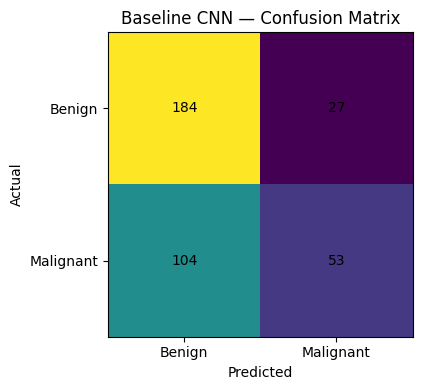

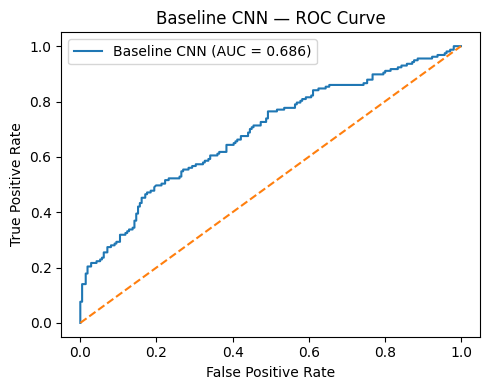

In [24]:
# Cell 10: Baseline CNN visual evaluation

# Confusion matrix
cm = np.array([[tn, fp],
               [fn, tp]])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Benign", "Malignant"])
ax.set_yticklabels(["Benign", "Malignant"])

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Baseline CNN - Confusion Matrix")

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j],
                ha="center", va="center")

plt.tight_layout()
plt.show()


# ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"Baseline CNN (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline CNN - ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

# Experiment 2 - Regularised CNN

The second experiment extends the baseline CNN with data augmentation,
batch normalisation, dropout and class weighting. These techniques are
intended to improve generalisation and reduce the bias observed in the
baseline model toward the benign class.

The same patient-level training, validation and held-out test sets are
used to ensure a fair comparison with the baseline CNN.

In [25]:
# Cell 11: Regularised CNN

from sklearn.utils.class_weight import compute_class_weight

tf.keras.backend.clear_session()
tf.random.set_seed(42)


# Class weights calculated ONLY from the training set
# ---------------------------------------------------------

train_labels = train_df["label"].map({
    "benign": 0,
    "malignant": 1
}).values

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_labels
)

class_weights = {
    0: float(weights[0]),
    1: float(weights[1])
}

print("Class weights:", class_weights)

# Data augmentation
# ---------------------------------------------------------

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
], name="data_augmentation")


# Regularised CNN
# ---------------------------------------------------------

regularised_model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.40),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.30),

    layers.Dense(1, activation="sigmoid")
], name="regularised_cnn")

regularised_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.AUC(name="auc")
    ]
)

regularised_model.summary()

Class weights: {0: 0.9198266522210184, 1: 1.095483870967742}


Model: "regularised_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,465 (400.25 KB)

 Trainable params: 102,017 (398.50 KB)

 Non-trainable params: 448 (1.75 KB)

In [26]:
# Cell 12: Train Regularised CNN

regularised_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

regularised_history = regularised_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weights,
    callbacks=regularised_callbacks,
    verbose=1
)

Epoch 1/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.5294 - auc: 0.5326 - loss: 0.7358 - val_accuracy: 0.5620 - val_auc: 0.5623 - val_loss: 0.6873 - learning_rate: 5.0000e-04
Epoch 2/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 155s 3s/step - accuracy: 0.5406 - auc: 0.5614 - loss: 0.7050 - val_accuracy: 0.5620 - val_auc: 0.5580 - val_loss: 0.6853 - learning_rate: 5.0000e-04
Epoch 3/25
53/54 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.5322 - auc: 0.5649 - loss: 0.6990
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
54/54 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.5359 - auc: 0.5565 - loss: 0.6989 - val_accuracy: 0.5620 - val_auc: 0.4716 - val_loss: 0.6874 - learning_rate: 5.0000e-04
Epoch 4/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 156s 3s/step - accuracy: 0.5607 - auc: 0.5884 - loss: 0.6846 - val_accuracy: 0.5620 - val_auc: 0.5092 - val_loss: 0.6854 - learning_rate: 2.5000e-04
Epoch 5/25
53/54 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.5541 - auc: 0.5734 - loss: 

In [27]:
# Cell 13: Final evaluation of Regularised CNN on held-out test set

# True labels are the same held-out test labels
y_true_reg = np.concatenate([
    y.numpy().ravel()
    for _, y in test_ds
]).astype(int)

# Predicted probabilities
y_prob_reg = regularised_model.predict(test_ds, verbose=1).ravel()

# Binary predictions
y_pred_reg = (y_prob_reg >= 0.5).astype(int)

# Confusion matrix
tn_r, fp_r, fn_r, tp_r = confusion_matrix(
    y_true_reg,
    y_pred_reg,
    labels=[0, 1]
).ravel()

accuracy_r = accuracy_score(y_true_reg, y_pred_reg)
precision_r = precision_score(y_true_reg, y_pred_reg, zero_division=0)
sensitivity_r = recall_score(y_true_reg, y_pred_reg, zero_division=0)

specificity_r = (
    tn_r / (tn_r + fp_r)
    if (tn_r + fp_r) else 0
)

f1_r = f1_score(y_true_reg, y_pred_reg, zero_division=0)
auc_r = roc_auc_score(y_true_reg, y_prob_reg)

regularised_results = {
    "Model": "Regularised CNN",
    "Accuracy": accuracy_r,
    "Precision": precision_r,
    "Sensitivity": sensitivity_r,
    "Specificity": specificity_r,
    "F1": f1_r,
    "ROC-AUC": auc_r
}

print("=== REGULARISED CNN - HELD-OUT TEST RESULTS ===")
print(f"Accuracy:    {accuracy_r:.4f}")
print(f"Precision:   {precision_r:.4f}")
print(f"Sensitivity: {sensitivity_r:.4f}")
print(f"Specificity: {specificity_r:.4f}")
print(f"F1-score:    {f1_r:.4f}")
print(f"ROC-AUC:     {auc_r:.4f}")

print("\nConfusion matrix:")
print(f"TN: {tn_r} | FP: {fp_r}")
print(f"FN: {fn_r} | TP: {tp_r}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step
=== REGULARISED CNN — HELD-OUT TEST RESULTS ===
Accuracy:    0.5707
Precision:   0.4667
Sensitivity: 0.0446
Specificity: 0.9621
F1-score:    0.0814
ROC-AUC:     0.5941

Confusion matrix:
TN: 203 | FP: 8
FN: 150 | TP: 7


# Experiment 3 - ResNet50 Transfer Learning

The third experiment applies transfer learning using ResNet50 pretrained
on ImageNet. The convolutional backbone is initially frozen and used as
a feature extractor, while a new binary classification head is trained
on CBIS-DDSM.

Transfer learning is investigated because the previous CNNs trained from
scratch showed limited ability to discriminate malignant lesions.
The same patient-level train, validation and held-out test sets are used
for direct comparison.

In [28]:
# Cell 14: ResNet50 transfer-learning model

tf.keras.backend.clear_session()
tf.random.set_seed(42)

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# Moderate augmentation
resnet_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.05),
], name="resnet_augmentation")

# ImageNet-pretrained backbone
resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Phase 1: freeze pretrained feature extractor
resnet_base.trainable = False

inputs = keras.Input(shape=(224, 224, 3))

x = resnet_augmentation(inputs)
x = preprocess_input(x)

# Keep BatchNorm inference behaviour stable
x = resnet_base(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.20)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

resnet_model = keras.Model(
    inputs,
    outputs,
    name="resnet50_transfer"
)

resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.AUC(name="auc")
    ]
)

resnet_model.summary()

print("\nResNet50 backbone trainable:", resnet_base.trainable)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "resnet50_transfer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet_augmentation │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ resnet_augmentat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ resnet_augmentat… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ resnet_augmentat… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    262,272 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        129 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


ResNet50 backbone trainable: False


In [29]:
# Cell 15: Phase 1 - train ResNet50 classification head

resnet_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=4,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

resnet_history = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=resnet_callbacks,
    verbose=1
)

Epoch 1/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.5571 - auc: 0.5640 - loss: 0.7544 - val_accuracy: 0.6042 - val_auc: 0.6403 - val_loss: 0.6634 - learning_rate: 0.0010
Epoch 2/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 156s 3s/step - accuracy: 0.6178 - auc: 0.6599 - loss: 0.6532 - val_accuracy: 0.5858 - val_auc: 0.6578 - val_loss: 0.6769 - learning_rate: 0.0010
Epoch 3/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.6266 - auc: 0.6666 - loss: 0.6515 - val_accuracy: 0.5699 - val_auc: 0.6395 - val_loss: 0.6974 - learning_rate: 0.0010
Epoch 4/15
53/54 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.6304 - auc: 0.6718 - loss: 0.6474
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
54/54 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step - accuracy: 0.6207 - auc: 0.6787 - loss: 0.6403 - val_accuracy: 0.5488 - val_auc: 0.6458 - val_loss: 0.7357 - learning_rate: 0.0010
Epoch 5/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.6514 - auc: 0.7111 - loss: 0.6187 - val_a

In [30]:
# Cell 16: Final evaluation of ResNet50 on held-out test set

y_true_res = np.concatenate([
    y.numpy().ravel()
    for _, y in test_ds
]).astype(int)

y_prob_res = resnet_model.predict(test_ds, verbose=1).ravel()
y_pred_res = (y_prob_res >= 0.5).astype(int)

tn_res, fp_res, fn_res, tp_res = confusion_matrix(
    y_true_res,
    y_pred_res,
    labels=[0, 1]
).ravel()

accuracy_res = accuracy_score(y_true_res, y_pred_res)
precision_res = precision_score(
    y_true_res, y_pred_res, zero_division=0
)
sensitivity_res = recall_score(
    y_true_res, y_pred_res, zero_division=0
)

specificity_res = (
    tn_res / (tn_res + fp_res)
    if (tn_res + fp_res) else 0
)

f1_res = f1_score(
    y_true_res, y_pred_res, zero_division=0
)

auc_res = roc_auc_score(
    y_true_res, y_prob_res
)

resnet_results = {
    "Model": "ResNet50 Transfer Learning",
    "Accuracy": accuracy_res,
    "Precision": precision_res,
    "Sensitivity": sensitivity_res,
    "Specificity": specificity_res,
    "F1": f1_res,
    "ROC-AUC": auc_res
}

print("=== RESNET50 - HELD-OUT TEST RESULTS ===")
print(f"Accuracy:    {accuracy_res:.4f}")
print(f"Precision:   {precision_res:.4f}")
print(f"Sensitivity: {sensitivity_res:.4f}")
print(f"Specificity: {specificity_res:.4f}")
print(f"F1-score:    {f1_res:.4f}")
print(f"ROC-AUC:     {auc_res:.4f}")

print("\nConfusion matrix:")
print(f"TN: {tn_res} | FP: {fp_res}")
print(f"FN: {fn_res} | TP: {tp_res}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step
=== RESNET50 — HELD-OUT TEST RESULTS ===
Accuracy:    0.6141
Precision:   0.5309
Sensitivity: 0.8217
Specificity: 0.4597
F1-score:    0.6450
ROC-AUC:     0.7001

Confusion matrix:
TN: 97 | FP: 114
FN: 28 | TP: 129


## Experiment 3B - ResNet50 Fine-Tuning

After training the classification head with the ResNet50 backbone frozen,
a second training phase fine-tunes the upper layers of the pretrained
network. A low learning rate is used to avoid substantially changing the
ImageNet features already learned by the network.

In [31]:
# CELL 17 - RESNET50 FINE-TUNING

# Unfreeze the ResNet50 backbone so that some of its higher-level
# features can adapt to the mammography dataset.
resnet_base.trainable = True

# I only want to fine-tune the last 30 layers.
# Earlier layers learn more general image features, so I keep them frozen.
for layer in resnet_base.layers[:-30]:
    layer.trainable = False

# Batch Normalisation layers are kept frozen because updating their
# statistics on a relatively small medical dataset can make training unstable.
for layer in resnet_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# After changing which layers are trainable, the model must be compiled again.
# A much smaller learning rate is used for fine-tuning so that the pretrained
# weights are adjusted gradually rather than overwritten.
resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.AUC(name="auc")
    ]
)

# Show how much of the network is now being updated.
trainable_layers = sum(layer.trainable for layer in resnet_base.layers)

print("Total ResNet50 layers:", len(resnet_base.layers))
print("Trainable backbone layers:", trainable_layers)

Total ResNet50 layers: 175
Trainable backbone layers: 21


In [32]:
# CELL 18 - TRAIN FINE-TUNED RESNET50

# Early stopping prevents unnecessary training once validation AUC
# stops improving. The best weights are restored automatically.
fine_tune_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        restore_best_weights=True
    ),

    # Reduce the learning rate further if validation performance stalls.
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

# Fine-tune for only a small number of epochs.
# The objective is to adapt the pretrained features, not retrain ResNet50
# from scratch.
fine_tune_history = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=fine_tune_callbacks,
    verbose=1
)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 157s 3s/step - accuracy: 0.6325 - auc: 0.6914 - loss: 0.6332 - val_accuracy: 0.5805 - val_auc: 0.6621 - val_loss: 0.6816 - learning_rate: 1.0000e-05
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.6396 - auc: 0.6976 - loss: 0.6296 - val_accuracy: 0.5831 - val_auc: 0.6689 - val_loss: 0.6815 - learning_rate: 1.0000e-05
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.6514 - auc: 0.7211 - loss: 0.6098 - val_accuracy: 0.5805 - val_auc: 0.6667 - val_loss: 0.7187 - learning_rate: 1.0000e-05
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.6661 - auc: 0.7354 - loss: 0.5974 - val_accuracy: 0.6121 - val_auc: 0.6791 - val_loss: 0.6627 - learning_rate: 1.0000e-05
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.6920 - auc: 0.7722 - loss: 0.5684 - val_accuracy: 0.6016 - val_auc: 0.6842 - val_loss: 0.6955 - learning_rate: 1.0000e-05
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.

In [33]:
# CELL 19 - FINE-TUNED RESNET50 FINAL EVALUATION

# Get the ground-truth labels from the held-out test dataset.
# These images were not used during model training or validation.
y_true_ft = np.concatenate([
    y.numpy().ravel()
    for _, y in test_ds
]).astype(int)

# Generate probability predictions for the malignant class.
# The sigmoid output returns values between 0 and 1.
y_prob_ft = resnet_model.predict(
    test_ds,
    verbose=1
).ravel()

# Convert probabilities into binary predictions.
# A threshold of 0.5 is used consistently across all models.
y_pred_ft = (y_prob_ft >= 0.5).astype(int)

# Calculate the confusion matrix.
# Class 0 = benign and class 1 = malignant.
tn_ft, fp_ft, fn_ft, tp_ft = confusion_matrix(
    y_true_ft,
    y_pred_ft,
    labels=[0, 1]
).ravel()

# Calculate the same metrics used for the previous experiments
# so that all models can be compared fairly.
accuracy_ft = accuracy_score(y_true_ft, y_pred_ft)

precision_ft = precision_score(
    y_true_ft,
    y_pred_ft,
    zero_division=0
)

sensitivity_ft = recall_score(
    y_true_ft,
    y_pred_ft,
    zero_division=0
)

# Specificity measures how well the model identifies benign cases.
specificity_ft = (
    tn_ft / (tn_ft + fp_ft)
    if (tn_ft + fp_ft) else 0
)

f1_ft = f1_score(
    y_true_ft,
    y_pred_ft,
    zero_division=0
)

# ROC-AUC uses the probability predictions rather than
# the thresholded binary predictions.
auc_ft = roc_auc_score(
    y_true_ft,
    y_prob_ft
)

# Store the results so they can later be included in the
# final model-comparison table.
finetuned_results = {
    "Model": "Fine-tuned ResNet50",
    "Accuracy": accuracy_ft,
    "Precision": precision_ft,
    "Sensitivity": sensitivity_ft,
    "Specificity": specificity_ft,
    "F1": f1_ft,
    "ROC-AUC": auc_ft
}

print("=== FINE-TUNED RESNET50 - HELD-OUT TEST RESULTS ===")
print(f"Accuracy:    {accuracy_ft:.4f}")
print(f"Precision:   {precision_ft:.4f}")
print(f"Sensitivity: {sensitivity_ft:.4f}")
print(f"Specificity: {specificity_ft:.4f}")
print(f"F1-score:    {f1_ft:.4f}")
print(f"ROC-AUC:     {auc_ft:.4f}")

print("\nConfusion matrix:")
print(f"TN: {tn_ft} | FP: {fp_ft}")
print(f"FN: {fn_ft} | TP: {tp_ft}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step
=== FINE-TUNED RESNET50 — HELD-OUT TEST RESULTS ===
Accuracy:    0.6332
Precision:   0.5458
Sensitivity: 0.8344
Specificity: 0.4834
F1-score:    0.6599
ROC-AUC:     0.7170

Confusion matrix:
TN: 102 | FP: 109
FN: 26 | TP: 131


# Model Comparison

All models are evaluated on the same held-out patient-level test set.
The comparison includes overall discrimination (ROC-AUC), classification
performance, and the clinically relevant trade-off between sensitivity
and specificity.

In [34]:
# CELL 20 - FINAL MODEL COMPARISON

# Combined the results saved after each experiment.
# Using the same metrics and test set makes the comparison consistent.
results_df = pd.DataFrame([
    baseline_results,
    regularised_results,
    resnet_results,
    finetuned_results
])

# Round values only for display.
display_results = results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Sensitivity",
    "Specificity",
    "F1",
    "ROC-AUC"
]

display_results[metric_columns] = (
    display_results[metric_columns].round(4)
)

print("=== FINAL MODEL COMPARISON ===")
display(display_results)

=== FINAL MODEL COMPARISON ===


,Model,Accuracy,Precision,Sensitivity,Specificity,F1,ROC-AUC
0,Baseline CNN,0.6440,0.6625,0.3376,0.8720,0.4473,0.6864
1,Regularised CNN,0.5707,0.4667,0.0446,0.9621,0.0814,0.5941
2,ResNet50 Transfer Learning,0.6141,0.5309,0.8217,0.4597,0.6450,0.7001
3,Fine-tuned ResNet50,0.6332,0.5458,0.8344,0.4834,0.6599,0.7170


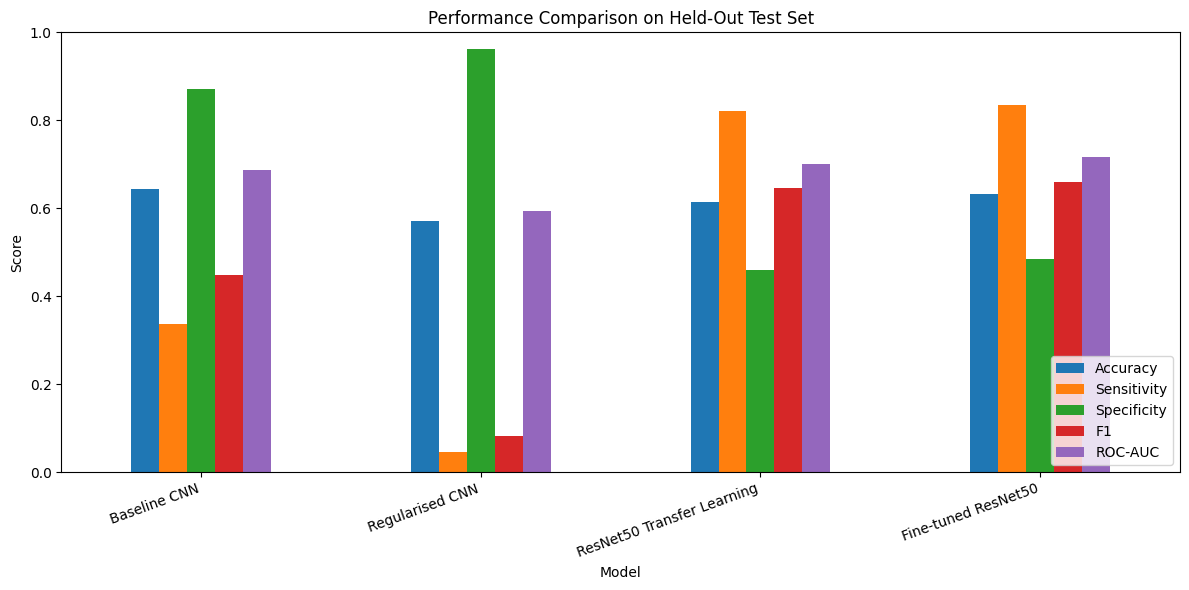

In [35]:
# CELL 21 - COMPARISON OF MODEL PERFORMANCE

# Plot the main evaluation metrics together.
# This makes the different sensitivity/specificity trade-offs
# between the models easier to see than from accuracy alone.
comparison_plot = results_df.set_index("Model")[
    ["Accuracy", "Sensitivity", "Specificity", "F1", "ROC-AUC"]
]

ax = comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title("Performance Comparison on Held-Out Test Set")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_xlabel("Model")

plt.xticks(rotation=20, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

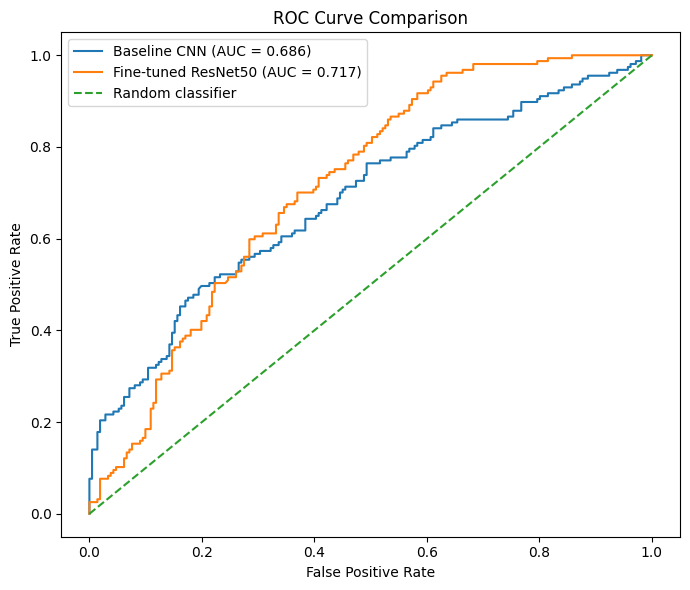

In [36]:
# CELL 22 - ROC CURVES FOR BASELINE AND FINAL RESNET50

# Compare probability discrimination of the baseline CNN
# with the final fine-tuned transfer-learning model.
fpr_base, tpr_base, _ = roc_curve(y_true, y_prob)
fpr_ft, tpr_ft, _ = roc_curve(y_true_ft, y_prob_ft)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr_base,
    tpr_base,
    label=f"Baseline CNN (AUC = {auc:.3f})"
)

plt.plot(
    fpr_ft,
    tpr_ft,
    label=f"Fine-tuned ResNet50 (AUC = {auc_ft:.3f})"
)

# The diagonal represents random discrimination (AUC = 0.5).
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# Explainability - Grad-CAM

Grad-CAM is applied to the final fine-tuned ResNet50 model to investigate
which image regions contribute to its predictions.

The objective is not to claim that the heat maps provide a clinical
explanation, but to inspect whether the model appears to focus on
meaningful regions of the mammogram and to identify possible failure cases.

In [37]:
# CELL 23 - PREPARE GRAD-CAM FOR THE FINAL RESNET50 MODEL

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Find the last convolutional layer in the ResNet50 backbone.
# Grad-CAM uses the feature maps from this layer because they retain
# spatial information while representing high-level image features.
last_conv_layer_name = None

for layer in reversed(resnet_base.layers):
    if isinstance(layer, layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print("Last convolutional layer:", last_conv_layer_name)

Last convolutional layer: conv5_block3_3_conv


In [39]:
# CELL 24 - GRAD-CAM FUNCTION FOR RESNET50

# Get the final convolutional layer from the ResNet50 backbone.
# This layer contains the spatial feature maps that Grad-CAM will use.
last_conv_layer = resnet_base.get_layer("conv5_block3_3_conv")

# Create a helper model that returns:
# 1. the activations from the final convolutional layer, and
# 2. the final prediction from my complete model.

# Because ResNet50 is nested inside my classification model, I first
# create a model that exposes the convolutional features of the backbone.
backbone_grad_model = keras.Model(
    inputs=resnet_base.input,
    outputs=[
        last_conv_layer.output,
        resnet_base.output
    ]
)

# Get the layers that form my classification head after ResNet50.
global_pool_layer = resnet_model.get_layer("global_average_pooling2d")
dropout_1_layer = resnet_model.get_layer("dropout")
dense_layer = resnet_model.get_layer("dense")
dropout_2_layer = resnet_model.get_layer("dropout_1")
output_layer = resnet_model.get_layer("dense_1")


def make_gradcam_heatmap(img_batch):
    """
    Generate a Grad-CAM heatmap for one preprocessed image batch.

    The function follows the same path used by the final ResNet50 model:
    preprocessing -> ResNet50 features -> classification head.
    """

    # ResNet50 expects ImageNet preprocessing rather than simple
    # division by 255, so I apply the same preprocessing used in training.
    processed_images = preprocess_input(
        tf.cast(img_batch, tf.float32)
    )

    # GradientTape records the operations needed to determine how much
    # each convolutional feature contributed to the malignant prediction.
    with tf.GradientTape() as tape:

        conv_outputs, backbone_output = backbone_grad_model(
            processed_images,
            training=False
        )

        # Pass the backbone features through the classification head.
        x = global_pool_layer(backbone_output)
        x = dropout_1_layer(x, training=False)
        x = dense_layer(x)
        x = dropout_2_layer(x, training=False)
        prediction = output_layer(x)

        # The sigmoid output represents the probability of class 1,
        # which in this project corresponds to malignant.
        malignant_score = prediction[:, 0]

    # Calculate the gradient of the malignant score with respect
    # to the final convolutional feature maps.
    gradients = tape.gradient(
        malignant_score,
        conv_outputs
    )

    # Average the gradients across the spatial dimensions.
    # These values represent the importance of each feature map.
    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2)
    )

    # Remove the batch dimension from the feature maps.
    conv_outputs = conv_outputs[0]

    # Weight each feature map by its importance.
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_gradients,
        axis=-1
    )

    # Grad-CAM keeps only positive contributions to the target class.
    heatmap = tf.maximum(heatmap, 0)

    # Normalise values to the range 0–1 for visualisation.
    max_value = tf.reduce_max(heatmap)

    if max_value > 0:
        heatmap = heatmap / max_value

    return heatmap.numpy()

In [40]:
# CELL 25 - TEST GRAD-CAM ON ONE HELD-OUT MAMMOGRAM

# Take one batch from the held-out test dataset.
# I use the test set only for final evaluation and visual analysis.
for test_images, test_labels in test_ds.take(1):
    sample_image = test_images[0]
    sample_label = int(test_labels[0].numpy()[0])
    break

# Add a batch dimension because the model expects
# input with shape (batch, height, width, channels).
sample_batch = tf.expand_dims(
    sample_image,
    axis=0
)

# Generate the Grad-CAM heatmap.
heatmap = make_gradcam_heatmap(sample_batch)

# Get the model's malignant probability for the same image.
prediction_probability = float(
    resnet_model.predict(
        sample_batch,
        verbose=0
    )[0][0]
)

predicted_label = (
    "Malignant"
    if prediction_probability >= 0.5
    else "Benign"
)

true_label = (
    "Malignant"
    if sample_label == 1
    else "Benign"
)

print("True label:", true_label)
print("Predicted label:", predicted_label)
print(
    "Malignant probability:",
    round(prediction_probability, 4)
)

print("Grad-CAM heatmap shape:", heatmap.shape)

True label: Benign
Predicted label: Malignant
Malignant probability: 0.5984
Grad-CAM heatmap shape: (7, 7)


In [41]:
# CELL 26 - SELECT REPRESENTATIVE TEST CASES

# I select one example of each possible classification outcome.
# This avoids showing only successful predictions and gives a more
# balanced view of how the final model behaves.

example_cases = {
    "True Negative": None,
    "True Positive": None,
    "False Positive": None,
    "False Negative": None
}

# Go through the held-out test set until one example of
# each classification outcome has been found.
for images, labels in test_ds:

    probabilities = resnet_model.predict(
        images,
        verbose=0
    ).ravel()

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    labels_np = (
        labels.numpy()
        .ravel()
        .astype(int)
    )

    for image, true_label, pred_label, probability in zip(
        images,
        labels_np,
        predictions,
        probabilities
    ):

        # Benign case correctly classified as benign.
        if true_label == 0 and pred_label == 0:
            case_name = "True Negative"

        # Malignant case correctly classified as malignant.
        elif true_label == 1 and pred_label == 1:
            case_name = "True Positive"

        # Benign case incorrectly classified as malignant.
        elif true_label == 0 and pred_label == 1:
            case_name = "False Positive"

        # Malignant case incorrectly classified as benign.
        else:
            case_name = "False Negative"

        # Keep only the first example found for each category.
        if example_cases[case_name] is None:
            example_cases[case_name] = {
                "image": image,
                "true_label": true_label,
                "pred_label": pred_label,
                "probability": float(probability)
            }

    # Stop searching once all four categories have been found.
    if all(
        value is not None
        for value in example_cases.values()
    ):
        break


print("=== REPRESENTATIVE TEST CASES ===")

for case_name, case in example_cases.items():

    if case is None:
        print(case_name, "-> not found")
        continue

    print(
        f"{case_name}: "
        f"true={case['true_label']}, "
        f"predicted={case['pred_label']}, "
        f"malignant_probability={case['probability']:.4f}"
    )

=== REPRESENTATIVE TEST CASES ===
True Negative: true=0, predicted=0, malignant_probability=0.4073
True Positive: true=1, predicted=1, malignant_probability=0.8346
False Positive: true=0, predicted=1, malignant_probability=0.5984
False Negative: true=1, predicted=0, malignant_probability=0.4713


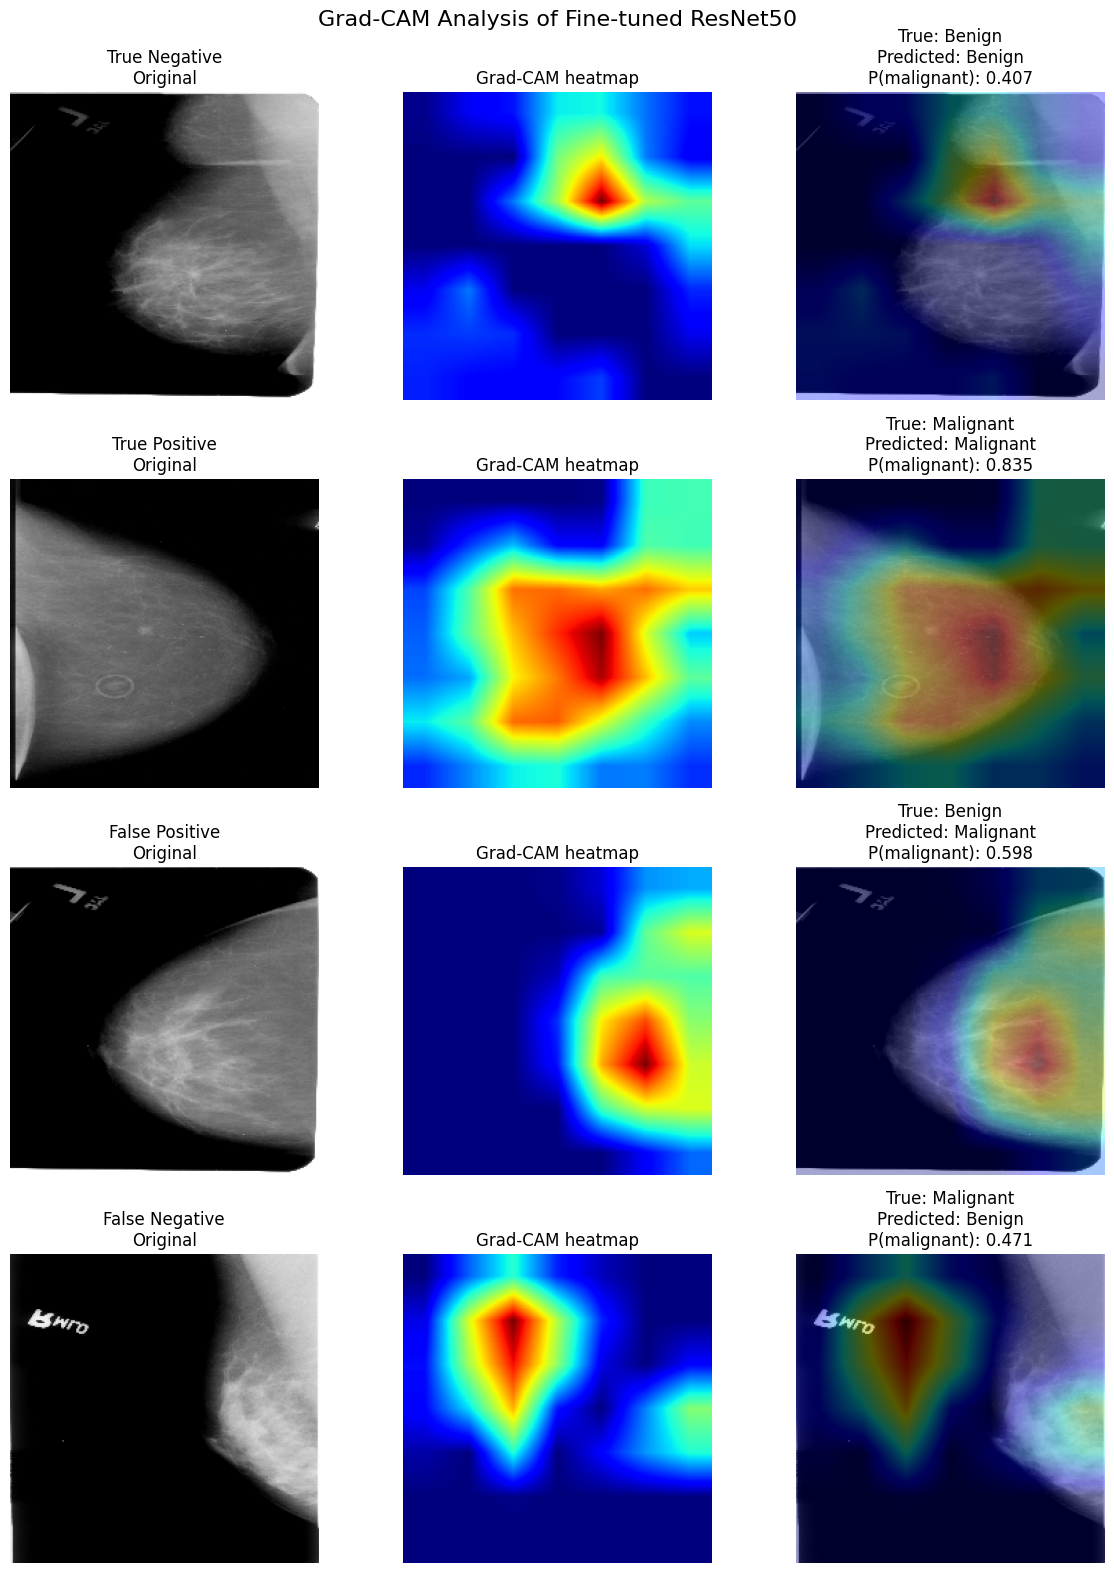

In [53]:
# CELL 27 - GRAD-CAM VISUALISATION OF REPRESENTATIVE CASES

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
import numpy as np

# I show one example of each classification outcome:
# true negative, true positive, false positive and false negative.
# This gives a balanced view of both correct predictions and errors.

fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(12, 16)
)

for row, (case_name, case) in enumerate(example_cases.items()):

    # Retrieve the original test image selected in the previous cell.
    image = case["image"]

    # Grad-CAM expects a batch dimension, so I temporarily
    # convert the single image into a batch of one image.
    image_batch = tf.expand_dims(image, axis=0)

    # Generate the Grad-CAM heatmap for this mammogram.
    heatmap = make_gradcam_heatmap(image_batch)

    # Resize the 7x7 Grad-CAM map to the same dimensions
    # as the input image so that it can be overlaid.
    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        (224, 224)
    ).numpy().squeeze()

    # Convert the original TensorFlow image to NumPy
    # and scale it to the 0-1 range for display.
    original = image.numpy().astype("float32")
    original_display = original / 255.0

    # Convert the heatmap into a coloured representation.
    # Red/yellow regions represent stronger model attention.
    coloured_heatmap = cm.jet(
        heatmap_resized
    )[:, :, :3]

    # Combine the original mammogram and heatmap.
    # The original image remains visible underneath the explanation.
    overlay = (
        0.65 * original_display +
        0.35 * coloured_heatmap
    )

    overlay = np.clip(overlay, 0, 1)

    # Convert numeric labels into readable text.
    true_name = (
        "Malignant"
        if case["true_label"] == 1
        else "Benign"
    )

    predicted_name = (
        "Malignant"
        if case["pred_label"] == 1
        else "Benign"
    )

    # Column 1: original mammogram.
    axes[row, 0].imshow(original_display)
    axes[row, 0].set_title(
        f"{case_name}\nOriginal"
    )
    axes[row, 0].axis("off")

    # Column 2: Grad-CAM heatmap by itself.
    axes[row, 1].imshow(
        heatmap_resized,
        cmap="jet"
    )
    axes[row, 1].set_title(
        "Grad-CAM heatmap"
    )
    axes[row, 1].axis("off")

    # Column 3: heatmap overlaid on the mammogram.
    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(
        f"True: {true_name}\n"
        f"Predicted: {predicted_name}\n"
        f"P(malignant): {case['probability']:.3f}"
    )
    axes[row, 2].axis("off")

plt.suptitle(
    "Grad-CAM Analysis of Fine-tuned ResNet50",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [43]:
# CELL 28 - SAVING FINAL MODEL AND EXPERIMENTAL RESULTS

from pathlib import Path
import json

# Create a folder for the final project artefacts.
# Keeping the model and results together makes it easier to
# reproduce the demo and use the same values in the final report.
OUTPUT_DIR = Path("/content/final_project_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Save the final fine-tuned ResNet50 model.
# The .keras format stores the architecture and trained weights.
model_path = OUTPUT_DIR / "breast_cancer_resnet50_final.keras"

resnet_model.save(model_path)

# Save the comparison table as CSV so that the exact experimental
# results can be reused later without manually copying values.
results_path = OUTPUT_DIR / "model_comparison.csv"
results_df.to_csv(results_path, index=False)

# Save important information about the final experiment.
# This provides a simple record of the dataset split and final model.
experiment_summary = {
    "dataset": "CBIS-DDSM",
    "total_images": 2445,
    "train_images": 1698,
    "validation_images": 379,
    "test_images": 368,
    "total_patients": 1245,
    "split_method": "patient-level 70/15/15",
    "random_seed": 42,
    "final_model": "Fine-tuned ResNet50",
    "test_accuracy": float(accuracy_ft),
    "test_precision": float(precision_ft),
    "test_sensitivity": float(sensitivity_ft),
    "test_specificity": float(specificity_ft),
    "test_f1": float(f1_ft),
    "test_roc_auc": float(auc_ft)
}

summary_path = OUTPUT_DIR / "experiment_summary.json"

with open(summary_path, "w") as f:
    json.dump(
        experiment_summary,
        f,
        indent=4
    )

print("Final model saved to:", model_path)
print("Results saved to:", results_path)
print("Experiment summary saved to:", summary_path)

Final model saved to: /content/final_project_outputs/breast_cancer_resnet50_final.keras
Results saved to: /content/final_project_outputs/model_comparison.csv
Experiment summary saved to: /content/final_project_outputs/experiment_summary.json


In [44]:
# CELL 29 - PREPARE GRADIO DEMO

# Gradio provides a simple web interface around the trained model.
# This lets a user upload a mammogram and inspect both the prediction
# and the Grad-CAM explanation without interacting with the notebook.

!pip -q install gradio

import gradio as gr
from PIL import Image

In [68]:
# CELL 30 - DEMO PREDICTION FUNCTION


import cv2

def predict_mammogram(input_image, cam_intensity):
    """
    Classify an uploaded mammogram and generate a Grad-CAM overlay.

    The demo returns the predicted class, malignant probability,
    and a visual explanation from the final fine-tuned ResNet50.
    """

    # Convert the uploaded image to RGB because ResNet50 expects
    # three input channels.
    image = Image.fromarray(input_image).convert("RGB")

    # Resize the image to the same dimensions used during training.
    image = image.resize((224, 224))

    # Convert the image into a NumPy array.
    image_array = np.array(image).astype("float32")

    # Add the batch dimension expected by TensorFlow.
    image_batch = np.expand_dims(image_array, axis=0)


    # MODEL PREDICTION
    # ---------------------------------------------------------

    # Obtain the probability assigned to the malignant class.
    probability = float(
        resnet_model.predict(
            image_batch,
            verbose=0
        )[0][0]
    )

    # Use the same threshold used during model evaluation.
    predicted_class = (
        "Malignant"
        if probability >= 0.5
        else "Benign"
    )


    # GRAD-CAM
    # ---------------------------------------------------------

    # Generate Grad-CAM from the final ResNet50 convolutional layer.
    heatmap = make_gradcam_heatmap(
        tf.convert_to_tensor(image_batch)
    )

    # The original CAM is only 7 x 7, so it must be resized
    # to match the 224 x 224 mammogram.
    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        (224, 224)
    ).numpy().squeeze()


    # IMPROVE GRAD-CAM VISUALISATION
    # ---------------------------------------------------------

    # Use percentile-based normalisation to reduce the influence
    # of extreme CAM values. This was also used in my prototype.
    lo, hi = np.percentile(
        heatmap_resized,
        [1, 99]
    )

    if hi - lo < 1e-5:
        lo = heatmap_resized.min()
        hi = heatmap_resized.max()

    heatmap_normalised = np.clip(
        (heatmap_resized - lo) /
        (hi - lo + 1e-5),
        0,
        1
    )

    # Smooth the enlarged CAM because the original spatial
    # representation is only 7 x 7.
    heatmap_smooth = cv2.GaussianBlur(
        heatmap_normalised,
        (7, 7),
        0
    )

    # Convert the CAM into a coloured heatmap.
    heatmap_colour = cv2.applyColorMap(
        np.uint8(255 * heatmap_smooth),
        cv2.COLORMAP_TURBO
    )

    heatmap_colour = cv2.cvtColor(
        heatmap_colour,
        cv2.COLOR_BGR2RGB
    ).astype("float32") / 255.0

    # Scale the original mammogram to 0-1 for display.
    original_display = image_array / 255.0


    # BREAST-REGION MASK
    # ---------------------------------------------------------

    # Mammograms contain a large black background.
    # This simple mask prevents the coloured overlay from being
    # displayed over most of the empty background.
    gray_image = np.mean(
        original_display,
        axis=2
    )

    breast_mask = (
        gray_image > 0.05
    ).astype(np.float32)

    breast_mask_rgb = (
        breast_mask[..., np.newaxis]
    )

    # The mask affects only the displayed explanation.
    # It does not modify the image used for prediction.
    masked_heatmap = (
        heatmap_colour *
        breast_mask_rgb
    )


    # USER-CONTROLLED OVERLAY
    # ---------------------------------------------------------

    # The slider controls only the visual strength of Grad-CAM.
    # It does not affect the prediction or malignant probability.
    alpha = float(cam_intensity)

    overlay = (
        (1.0 - alpha) * original_display +
        alpha * masked_heatmap
    )

    overlay = np.clip(
        overlay,
        0,
        1
    )

    # Convert to the standard image format expected by Gradio.
    overlay_uint8 = (
        overlay * 255
    ).astype(np.uint8)


    # OUTPUT
    # ---------------------------------------------------------

    result_text = (
        f"Prediction: {predicted_class}\n"
        f"Malignant probability: {probability:.3f}"
    )

    return result_text, overlay_uint8

In [69]:
# CELL 31 - LAUNCH INTERACTIVE DEMO

# The interface is intentionally simple because the objective is
# to demonstrate the model and its explanation rather than create
# a production clinical application.

demo = gr.Interface(
    fn=predict_mammogram,

    # The prediction function receives two inputs:
    # 1. the uploaded mammogram
    # 2. the desired Grad-CAM overlay intensity
    inputs=[
        gr.Image(
            type="numpy",
            label="Upload mammogram"
        ),

        gr.Slider(
            minimum=0.0,
            maximum=0.7,
            value=0.30,
            step=0.05,
            label="Grad-CAM overlay intensity"
        )
    ],

    # The application returns the model prediction and
    # the mammogram with the Grad-CAM explanation overlaid.
    outputs=[
        gr.Textbox(
            label="Model prediction"
        ),

        gr.Image(
            label="Grad-CAM explanation"
        )
    ],

    title="Deep Learning-Assisted Breast Cancer Detection",

    description=(
        "Upload a mammogram. "
        "Research prototype only - not for clinical diagnosis."
    )
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b0af2e7428826bebd4.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [49]:
# CELL 32 - SAVE A TEST IMAGE FOR THE DEMO

# I use a true-positive example from the held-out test set
# to verify that the complete Gradio pipeline works correctly.
demo_image = example_cases["True Positive"]["image"].numpy()

# Save the TensorFlow image as a standard JPEG file
# so that it can be uploaded through the Gradio interface.
demo_path = "/content/demo_true_positive.jpg"

Image.fromarray(
    demo_image.astype(np.uint8)
).save(demo_path)

print("Demo image saved to:", demo_path)
print("Known ground truth: Malignant")
print(
    "Expected malignant probability:",
    round(example_cases["True Positive"]["probability"], 4)
)

Demo image saved to: /content/demo_true_positive.jpg
Known ground truth: Malignant
Expected malignant probability: 0.8346


# Experiment  - Aiming for a better GRANT CAM





In [60]:

# CELL 34 - FIND A GROUND-TRUTH ROI MASK

# CBIS-DDSM provides lesion masks in the metadata.
# I first look for malignant cases from my held-out test patients
# that have an ROI mask path available.

test_malignant_df = test_df[
    (test_df["label"] == "malignant") &
    (test_df["ROI mask file path"].notna())
].copy()

print("Malignant test records with ROI metadata:",
      len(test_malignant_df))

# Display a few metadata fields so I can verify that the
# mammogram and ROI information belong to the same record.
display(
    test_malignant_df[
        [
            "patient_id",
            "abnormality type",
            "image view",
            "pathology",
            "img",
            "ROI mask file path"
        ]
    ].head(5)
)

Malignant test records with ROI metadata: 157


,patient_id,abnormality type,image view,pathology,img,ROI mask file path
14,P_00023,mass,CC,MALIGNANT,/content/jpeg/1.3.6.1.4.1.9590.100.1.2.1239688...,Mass-Training_P_00023_RIGHT_CC_1/1.3.6.1.4.1.9...
15,P_00023,mass,MLO,MALIGNANT,/content/jpeg/1.3.6.1.4.1.9590.100.1.2.4176392...,Mass-Training_P_00023_RIGHT_MLO_1/1.3.6.1.4.1....
32,P_00045,mass,CC,MALIGNANT,/content/jpeg/1.3.6.1.4.1.9590.100.1.2.4276291...,Mass-Training_P_00045_LEFT_CC_1/1.3.6.1.4.1.95...
33,P_00045,mass,MLO,MALIGNANT,/content/jpeg/1.3.6.1.4.1.9590.100.1.2.9440128...,Mass-Training_P_00045_LEFT_MLO_1/1.3.6.1.4.1.9...
34,P_00046,mass,MLO,MALIGNANT,/content/jpeg/1.3.6.1.4.1.9590.100.1.2.1718160...,Mass-Training_P_00046_RIGHT_MLO_1/1.3.6.1.4.1....


In [61]:

# CELL 35 - LOAD ONE GROUND-TRUTH LESION MASK

# I select the first malignant test record with ROI metadata.
# This record provides both the full mammogram and the
# corresponding lesion-mask path supplied by CBIS-DDSM.
roi_case = test_malignant_df.iloc[0]

mammogram_path = roi_case["img"]
roi_metadata_path = roi_case["ROI mask file path"]

print("Patient:", roi_case["patient_id"])
print("Abnormality:", roi_case["abnormality type"])
print("View:", roi_case["image view"])
print("Pathology:", roi_case["pathology"])

print("\nMammogram:")
print(mammogram_path)

print("\nROI metadata path:")
print(roi_metadata_path)


# The CBIS-DDSM metadata path contains a DICOM series UID.
# The Kaggle version stores the converted JPEG files in
# directories named using these UIDs.
def find_jpg_from_metadata_path(metadata_path):

    # Extract every possible UID from the metadata path.
    uids = uid_re.findall(str(metadata_path))

    candidate_files = []

    for uid in uids:

        uid_directory = JPEG / uid

        if uid_directory.exists():

            # Search both the directory itself and any
            # nested directories for converted JPEG files.
            hits = glob.glob(
                str(uid_directory / "**" / "*.jpg"),
                recursive=True
            )

            candidate_files.extend(hits)

    return candidate_files


roi_candidates = find_jpg_from_metadata_path(
    roi_metadata_path
)

print("\nPossible ROI JPEG files found:")
print("Count:", len(roi_candidates))

for path in roi_candidates:
    print(path)

Patient: P_00023
Abnormality: mass
View: CC
Pathology: MALIGNANT

Mammogram:
/content/jpeg/1.3.6.1.4.1.9590.100.1.2.123968816011512951434814084172747879091/1-289.jpg

ROI metadata path:
Mass-Training_P_00023_RIGHT_CC_1/1.3.6.1.4.1.9590.100.1.2.332745218911042083414248014282525746282/1.3.6.1.4.1.9590.100.1.2.284159596213273410631233627161184420091/000001.dcm


Possible ROI JPEG files found:
Count: 2
/content/jpeg/1.3.6.1.4.1.9590.100.1.2.284159596213273410631233627161184420091/2-213.jpg
/content/jpeg/1.3.6.1.4.1.9590.100.1.2.284159596213273410631233627161184420091/1-214.jpg


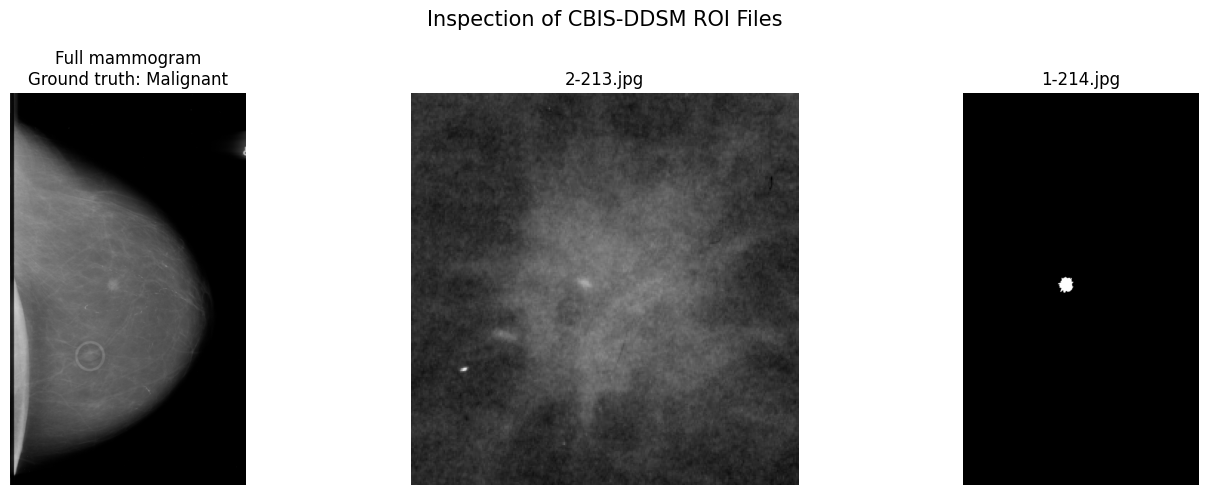

=== ROI CANDIDATE INFORMATION ===
2-213.jpg | shape: (265, 262) | min: 1 | max: 255 | unique values: 156
1-214.jpg | shape: (5491, 3301) | min: 0 | max: 255 | unique values: 16


In [62]:
# CELL 36 - INSPECT ROI CANDIDATE IMAGES

from PIL import Image

# The ROI series contains two converted JPEG files.
# I display both because one may be the cropped lesion image
# while the other may represent the binary lesion mask.
# I do not select one based only on its filename.

fig, axes = plt.subplots(
    1,
    len(roi_candidates) + 1,
    figsize=(15, 5)
)

# Display the corresponding full mammogram first.
full_image = Image.open(mammogram_path)

axes[0].imshow(
    full_image,
    cmap="gray"
)

axes[0].set_title(
    "Full mammogram\nGround truth: Malignant"
)

axes[0].axis("off")


# Display every image found in the ROI series.
for i, candidate_path in enumerate(
    roi_candidates,
    start=1
):

    candidate_image = Image.open(
        candidate_path
    )

    axes[i].imshow(
        candidate_image,
        cmap="gray"
    )

    axes[i].set_title(
        Path(candidate_path).name
    )

    axes[i].axis("off")


plt.suptitle(
    "Inspection of CBIS-DDSM ROI Files",
    fontsize=15
)

plt.tight_layout()
plt.show()


# Print image properties as an additional check.
print("=== ROI CANDIDATE INFORMATION ===")

for candidate_path in roi_candidates:

    candidate_image = Image.open(
        candidate_path
    )

    candidate_array = np.array(
        candidate_image
    )

    print(
        Path(candidate_path).name,
        "| shape:",
        candidate_array.shape,
        "| min:",
        candidate_array.min(),
        "| max:",
        candidate_array.max(),
        "| unique values:",
        len(np.unique(candidate_array))
    )

Full mammogram size: (3301, 5491)
Ground-truth mask size: (3301, 5491)


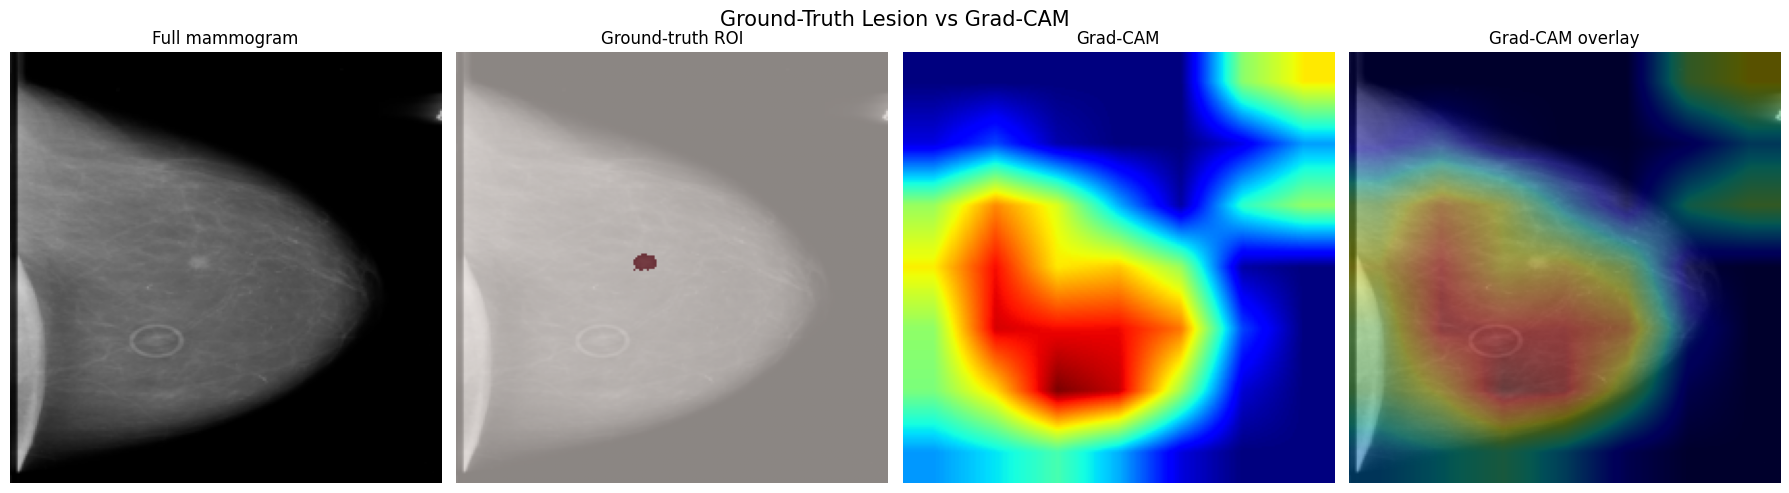

In [63]:
# CELL 37 - COMPARE GROUND-TRUTH ROI WITH GRAD-CAM


# From the previous inspection, the large mostly-black image
# corresponds to the ground-truth lesion mask.
roi_mask_path = [
    path for path in roi_candidates
    if np.array(Image.open(path)).shape[0] > 1000
][0]

# Load the full mammogram and ground-truth ROI mask.
full_mammogram = Image.open(
    mammogram_path
).convert("RGB")

ground_truth_mask = Image.open(
    roi_mask_path
).convert("L")

print("Full mammogram size:", full_mammogram.size)
print("Ground-truth mask size:", ground_truth_mask.size)

# Resize both images to the same dimensions used by the model.
# Nearest-neighbour interpolation is used for the mask so that
# the binary lesion boundaries are not blurred unnecessarily.
mammogram_224 = full_mammogram.resize(
    (224, 224)
)

mask_224 = ground_truth_mask.resize(
    (224, 224),
    resample=Image.Resampling.NEAREST
)

mammogram_array = np.array(
    mammogram_224
).astype("float32")

mask_array = np.array(
    mask_224
).astype("float32")

# Convert the ROI mask into a binary ground-truth mask.
# Any non-background region is treated as lesion annotation.
binary_mask = (
    mask_array > 127
).astype(np.float32)

# Generate Grad-CAM for exactly the same mammogram.
mammogram_batch = np.expand_dims(
    mammogram_array,
    axis=0
)

case_heatmap = make_gradcam_heatmap(
    tf.convert_to_tensor(mammogram_batch)
)

# Resize Grad-CAM from 7x7 to 224x224.
case_heatmap_224 = tf.image.resize(
    case_heatmap[..., np.newaxis],
    (224, 224)
).numpy().squeeze()

# VISUAL COMPARISON
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    4,
    figsize=(18, 5)
)

# Original mammogram
axes[0].imshow(
    mammogram_array.astype(np.uint8)
)
axes[0].set_title("Full mammogram")
axes[0].axis("off")

# Ground-truth lesion annotation
axes[1].imshow(
    mammogram_array.astype(np.uint8)
)
axes[1].imshow(
    binary_mask,
    cmap="Reds",
    alpha=0.55
)
axes[1].set_title("Ground-truth ROI")
axes[1].axis("off")

# Grad-CAM alone
axes[2].imshow(
    case_heatmap_224,
    cmap="jet"
)
axes[2].set_title("Grad-CAM")
axes[2].axis("off")

# Grad-CAM overlay
axes[3].imshow(
    mammogram_array.astype(np.uint8)
)
axes[3].imshow(
    case_heatmap_224,
    cmap="jet",
    alpha=0.35
)
axes[3].set_title("Grad-CAM overlay")
axes[3].axis("off")

plt.suptitle(
    "Ground-Truth Lesion vs Grad-CAM",
    fontsize=15
)

plt.tight_layout()
plt.show()

In [64]:
# CELL 38 - INSPECT RESNET50 SPATIAL FEATURE MAPS

# Grad-CAM currently uses the last convolutional layer, whose
# feature map is only 7 x 7. This may be too coarse to localise
# small mammographic lesions accurately.
#
# I inspect several ResNet50 stages with progressively higher
# spatial resolution before testing an alternative explanation.

candidate_layer_names = [
    "conv3_block4_out",   # typically 28 x 28
    "conv4_block6_out",   # typically 14 x 14
    "conv5_block3_out"    # typically 7 x 7
]

print("=== CANDIDATE FEATURE MAPS ===")

for layer_name in candidate_layer_names:

    layer = resnet_base.get_layer(layer_name)

    print(
        f"{layer_name}: {layer.output.shape}"
    )

=== CANDIDATE FEATURE MAPS ===
conv3_block4_out: (None, 28, 28, 512)
conv4_block6_out: (None, 14, 14, 1024)
conv5_block3_out: (None, 7, 7, 2048)


In [65]:
# CELL 39 - MULTI-RESOLUTION GRAD-CAM

def make_gradcam_from_layer(img_batch, layer_name):
    """
    Generate Grad-CAM using a selected ResNet50 feature layer.

    This allows me to compare whether higher-resolution feature maps
    provide better lesion localisation than the final 7 x 7 layer.
    """

    # Select the ResNet50 layer that will provide the spatial
    # feature maps used by Grad-CAM.
    target_layer = resnet_base.get_layer(layer_name)

    # Create a temporary model that exposes both the selected
    # feature maps and the final ResNet50 backbone output.
    feature_model = keras.Model(
        inputs=resnet_base.input,
        outputs=[
            target_layer.output,
            resnet_base.output
        ]
    )

    # Apply exactly the same ImageNet preprocessing used
    # by the ResNet50 classification model.
    processed_images = preprocess_input(
        tf.cast(img_batch, tf.float32)
    )

    with tf.GradientTape() as tape:

        feature_maps, backbone_output = feature_model(
            processed_images,
            training=False
        )

        # Pass the backbone output through the classification head
        # of my fine-tuned model.
        x = global_pool_layer(backbone_output)
        x = dropout_1_layer(x, training=False)
        x = dense_layer(x)
        x = dropout_2_layer(x, training=False)
        prediction = output_layer(x)

        # Class 1 corresponds to malignant.
        malignant_score = prediction[:, 0]

    # Measure how strongly each spatial feature contributes
    # to the malignant prediction.
    gradients = tape.gradient(
        malignant_score,
        feature_maps
    )

    # Average the gradients for each feature channel.
    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2)
    )

    feature_maps = feature_maps[0]

    # Combine feature maps using their gradient importance.
    heatmap = tf.reduce_sum(
        feature_maps * pooled_gradients,
        axis=-1
    )

    # Keep positive contributions only.
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalise the heatmap to 0-1.
    max_value = tf.reduce_max(heatmap)

    if max_value > 0:
        heatmap = heatmap / max_value

    return heatmap.numpy()


# Generate Grad-CAM at three different spatial resolutions
# for exactly the same malignant mammogram.
cam_28 = make_gradcam_from_layer(
    mammogram_batch,
    "conv3_block4_out"
)

cam_14 = make_gradcam_from_layer(
    mammogram_batch,
    "conv4_block6_out"
)

cam_7 = make_gradcam_from_layer(
    mammogram_batch,
    "conv5_block3_out"
)

print("28x28 CAM:", cam_28.shape)
print("14x14 CAM:", cam_14.shape)
print("7x7 CAM:", cam_7.shape)

28x28 CAM: (28, 28)
14x14 CAM: (14, 14)
7x7 CAM: (7, 7)


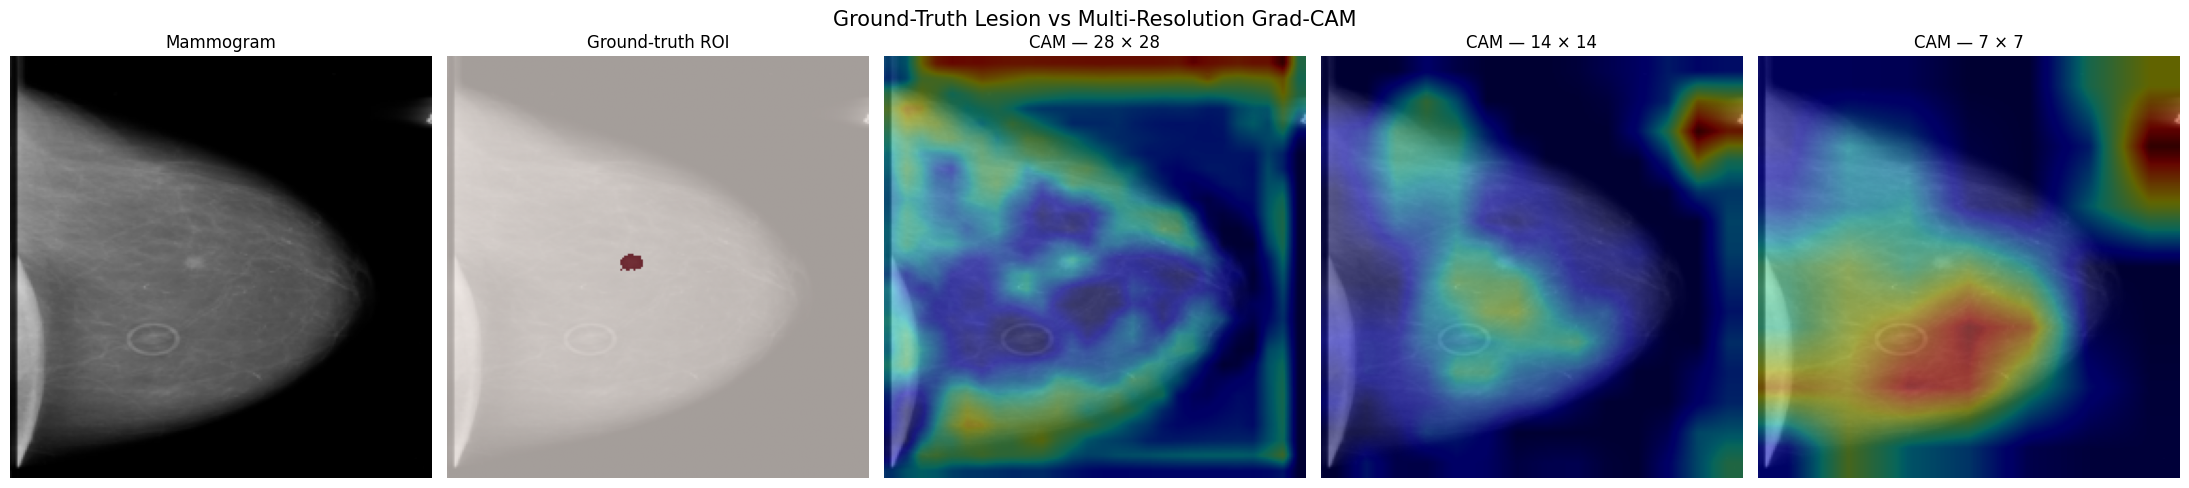

In [66]:

# CELL 40 - COMPARE CAM RESOLUTIONS WITH GROUND-TRUTH ROI

# Resize all CAMs to the same 224 x 224 space as the
# mammogram and ground-truth lesion mask.
def resize_cam(cam):

    return tf.image.resize(
        cam[..., np.newaxis],
        (224, 224)
    ).numpy().squeeze()


cam_28_224 = resize_cam(cam_28)
cam_14_224 = resize_cam(cam_14)
cam_7_224  = resize_cam(cam_7)


# Display the true lesion location beside the three CAM variants.
fig, axes = plt.subplots(
    1,
    5,
    figsize=(22, 5)
)

axes[0].imshow(
    mammogram_array.astype(np.uint8)
)
axes[0].set_title("Mammogram")
axes[0].axis("off")


axes[1].imshow(
    mammogram_array.astype(np.uint8)
)
axes[1].imshow(
    binary_mask,
    cmap="Reds",
    alpha=0.65
)
axes[1].set_title("Ground-truth ROI")
axes[1].axis("off")


axes[2].imshow(
    mammogram_array.astype(np.uint8)
)
axes[2].imshow(
    cam_28_224,
    cmap="jet",
    alpha=0.40
)
axes[2].set_title("CAM - 28 × 28")
axes[2].axis("off")


axes[3].imshow(
    mammogram_array.astype(np.uint8)
)
axes[3].imshow(
    cam_14_224,
    cmap="jet",
    alpha=0.40
)
axes[3].set_title("CAM - 14 × 14")
axes[3].axis("off")


axes[4].imshow(
    mammogram_array.astype(np.uint8)
)
axes[4].imshow(
    cam_7_224,
    cmap="jet",
    alpha=0.40
)
axes[4].set_title("CAM - 7 × 7")
axes[4].axis("off")


plt.suptitle(
    "Ground-Truth Lesion vs Multi-Resolution Grad-CAM",
    fontsize=15
)

plt.tight_layout()
plt.show()

In [67]:
# FINAL BACKUP

import shutil
from google.colab import files

# Compress the final trained model and experimental results.
shutil.make_archive(
    "/content/Ruy_Perez_Final_Project_Outputs",
    "zip",
    "/content/final_project_outputs"
)

# Download the backup to my local computer because
# Colab storage is temporary.
files.download(
    "/content/Ruy_Perez_Final_Project_Outputs.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>